# vLLM Performance Analysis

This notebook analyzes performance metrics from the load test.
Run `make perf` first to generate `metrics.csv`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 100

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv("metrics.csv")
print(f"Loaded {len(df)} records")
df.head(10)

Loaded 1134 records


,concurrency,prompt_type,ttft_ms,tpot,total_latency_ms,tokens_generated,stop_setting
0,1,short,3014.90,25.06,5329.25,58,none
1,1,short,106.32,17.44,622.39,9,none
2,1,short,244.09,29.86,545.50,9,none
3,1,short,97.86,26.77,882.18,21,double_newline
4,1,short,103.94,28.61,1397.05,37,double_newline
5,1,short,80.26,26.29,4949.64,128,double_newline
6,1,short,289.06,33.00,531.52,8,single_newline
7,1,short,100.06,26.95,434.07,9,single_newline
8,1,short,102.31,29.03,1101.21,29,single_newline
9,1,long,212.04,28.00,4783.27,128,none


## 1. Time-to-First-Token (TTFT) vs Concurrency

TTFT measures how quickly the server begins generating tokens.
Higher concurrency should increase TTFT as the server batches more requests.

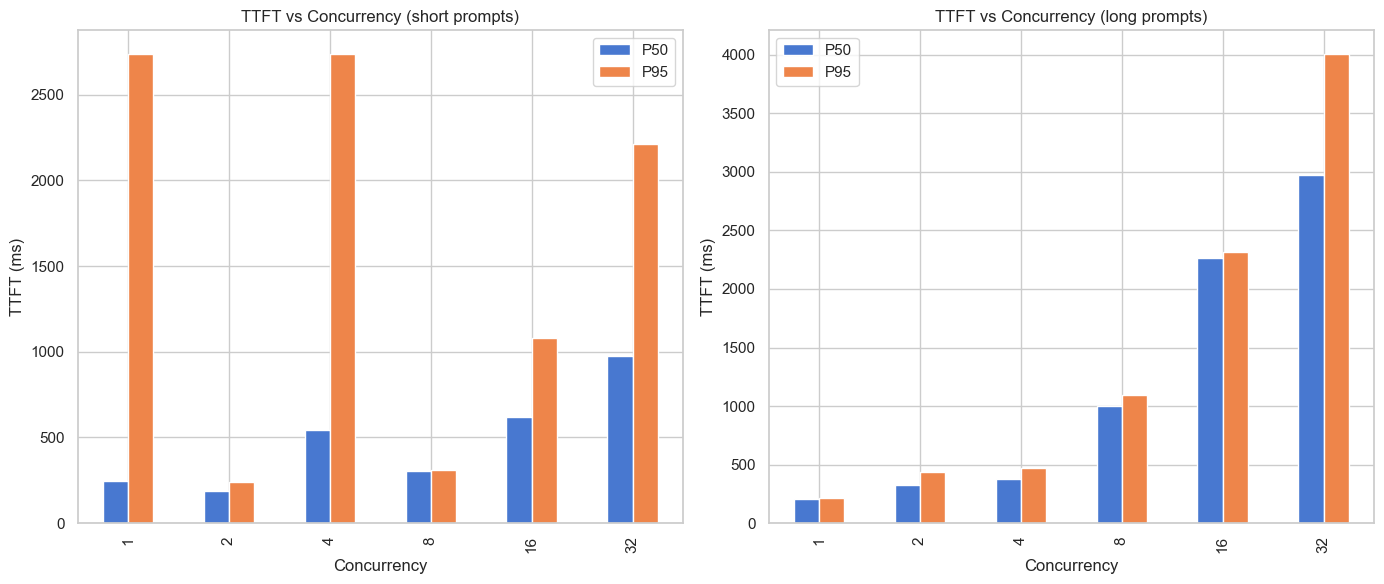

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, prompt_type in zip(axes, ["short", "long"]):
    subset = df[(df["prompt_type"] == prompt_type) & (df["stop_setting"] == "none")]
    stats = subset.groupby("concurrency")["ttft_ms"].agg(["median", lambda x: np.percentile(x, 95)])
    stats.columns = ["P50", "P95"]
    stats.plot(kind="bar", ax=ax)
    ax.set_title(f"TTFT vs Concurrency ({prompt_type} prompts)")
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("TTFT (ms)")
    ax.legend()

plt.tight_layout()
plt.savefig("ttft_vs_concurrency.png", bbox_inches="tight")
plt.show()

## 2. Throughput (Tokens/sec) vs Concurrency

Aggregate throughput should increase with concurrency due to continuous batching,
up to the point where the GPU is saturated.

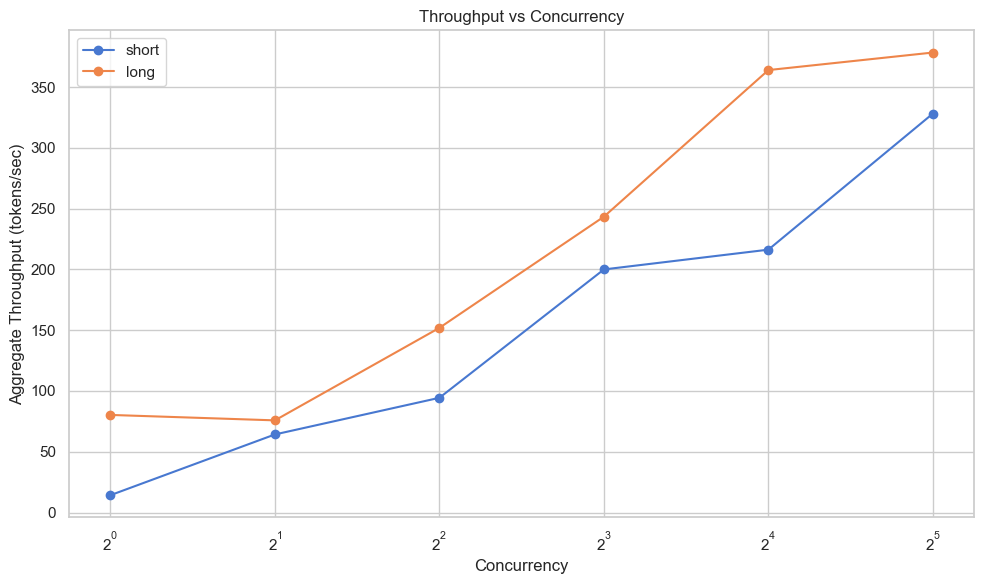

In [4]:
no_stop = df[df["stop_setting"] == "none"].copy()

agg_throughput = (
    no_stop.groupby(["concurrency", "prompt_type"])
    .agg(total_tokens=("tokens_generated", "sum"),
         total_time_ms=("total_latency_ms", "max"))
    .reset_index()
)
agg_throughput["throughput"] = agg_throughput["total_tokens"] / (agg_throughput["total_time_ms"] / 1000)

fig, ax = plt.subplots(figsize=(10, 6))
for ptype in ["short", "long"]:
    sub = agg_throughput[agg_throughput["prompt_type"] == ptype]
    ax.plot(sub["concurrency"], sub["throughput"], marker="o", label=ptype)

ax.set_xlabel("Concurrency")
ax.set_ylabel("Aggregate Throughput (tokens/sec)")
ax.set_title("Throughput vs Concurrency")
ax.legend()
ax.set_xscale("log", base=2)
plt.tight_layout()
plt.savefig("throughput_vs_concurrency.png", bbox_inches="tight")
plt.show()

## 3. Latency Distribution (Box Plots)

Box plots show the spread of end-to-end latency at each concurrency level.

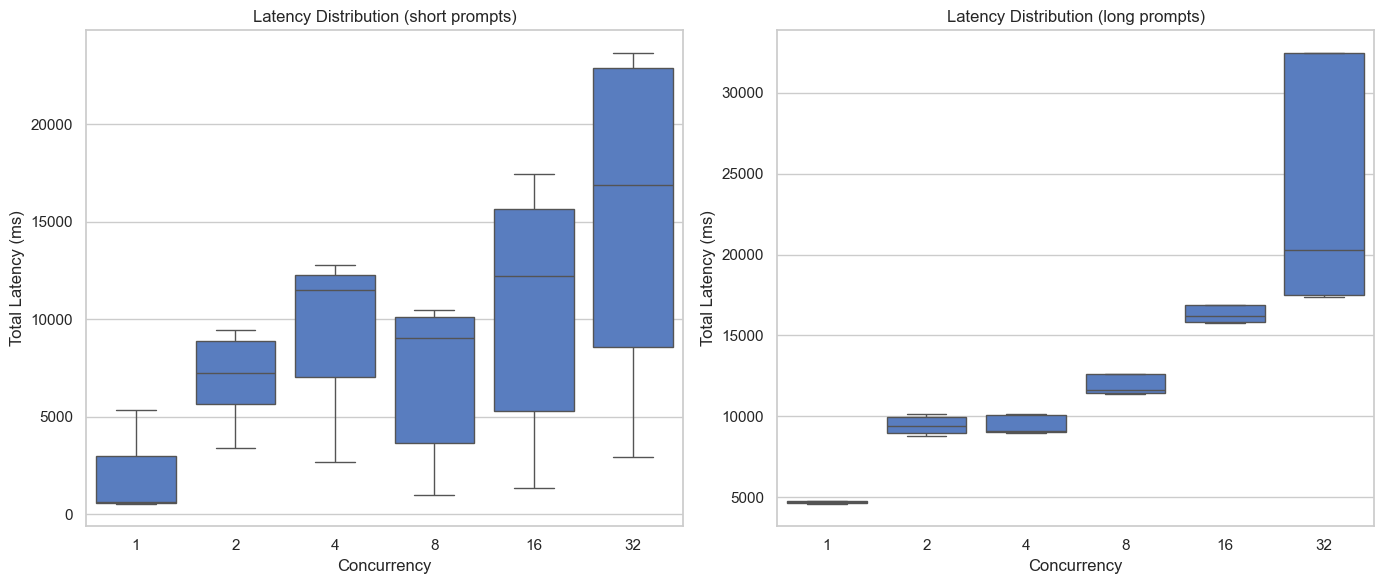

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, prompt_type in zip(axes, ["short", "long"]):
    subset = df[(df["prompt_type"] == prompt_type) & (df["stop_setting"] == "none")]
    sns.boxplot(data=subset, x="concurrency", y="total_latency_ms", ax=ax)
    ax.set_title(f"Latency Distribution ({prompt_type} prompts)")
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("Total Latency (ms)")

plt.tight_layout()
plt.savefig("latency_distribution.png", bbox_inches="tight")
plt.show()

## 4. Effect of Stop Sequences

Comparing how different stop-sequence settings affect latency and tokens generated.

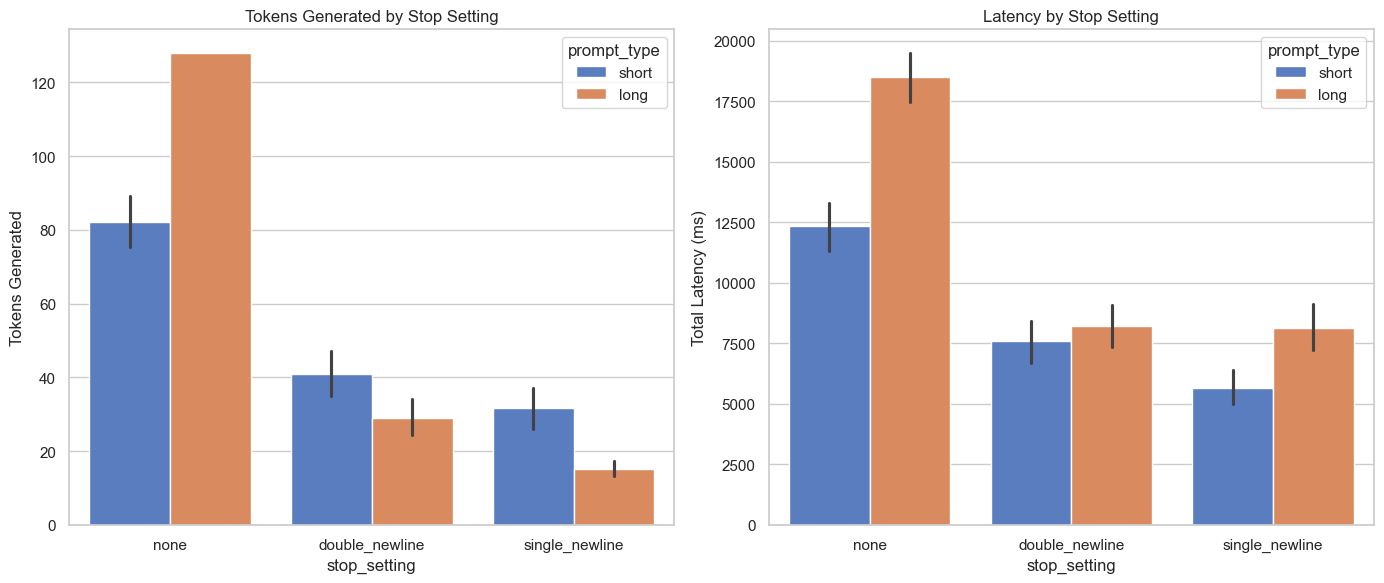

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Tokens generated by stop setting
sns.barplot(data=df, x="stop_setting", y="tokens_generated", hue="prompt_type", ax=axes[0])
axes[0].set_title("Tokens Generated by Stop Setting")
axes[0].set_ylabel("Tokens Generated")

# Latency by stop setting
sns.barplot(data=df, x="stop_setting", y="total_latency_ms", hue="prompt_type", ax=axes[1])
axes[1].set_title("Latency by Stop Setting")
axes[1].set_ylabel("Total Latency (ms)")

plt.tight_layout()
plt.savefig("stop_sequence_effect.png", bbox_inches="tight")
plt.show()

## 5. Summary Statistics

Percentile breakdown across all configurations.

In [7]:
summary = (
    df.groupby(["concurrency", "prompt_type", "stop_setting"])
    .agg(
        count=("ttft_ms", "count"),
        ttft_p50=("ttft_ms", "median"),
        ttft_p95=("ttft_ms", lambda x: np.percentile(x, 95)),
        ttft_p99=("ttft_ms", lambda x: np.percentile(x, 99)),
        latency_p50=("total_latency_ms", "median"),
        latency_p95=("total_latency_ms", lambda x: np.percentile(x, 95)),
        latency_p99=("total_latency_ms", lambda x: np.percentile(x, 99)),
        avg_tpot=("tpot", "mean"),
        avg_tokens=("tokens_generated", "mean"),
    )
    .round(2)
)

summary

count  ttft_p50  ttft_p95  ttft_p99  \
concurrency prompt_type stop_setting                                          
1           long        double_newline      3    179.62    182.38    182.63   
                        none                3    202.05    211.04    211.84   
                        single_newline      3    174.42    190.70    192.15   
            short       double_newline      3     97.86    103.33    103.82   
                        none                3    244.09   2737.82   2959.48   
                        single_newline      3    102.31    270.38    285.32   
2           long        double_newline      6    288.68    381.37    393.73   
                        none                6    323.71    433.07    445.81   
                        single_newline      6    258.85    286.39    292.55   
            short       double_newline      6    152.85    184.22    186.44   
                        none                6    189.89    238.35    248.08   
                        single_newline      6    108.32    231.65    244.47   
4           long        double_newline     12    389.75    397.69    398.66   
                        none               12    380.20    466.97    467.21   
                        single_newline     12    361.58    380.57    381.19   
            short       double_newline     12    181.02    412.03    520.76   
                        none               12    545.85   2736.50   2739.89   
                        single_newline     12    164.94    215.52    216.08   
8           long        double_newline     24    791.26    860.84    868.39   
                        none               24   1001.89   1096.25   1098.71   
                        single_newline     24    734.44    742.43    743.07   
            short       double_newline     24    396.14    478.83    595.17   
                        none               24    301.56    308.45    313.09   
                        single_newline     24    208.12    228.12    230.53   
16          long        double_newline     48   2096.03   2823.33   2831.11   
                        none               48   2264.82   2315.66   2354.00   
                        single_newline     48   1306.49   1608.82   1616.09   
            short       double_newline     48    802.78   1379.57   3501.09   
                        none               48    620.72   1077.76   1125.27   
                        single_newline     48    564.00    676.49    681.31   
32          long        double_newline     96   2785.78   3098.61   3100.97   
                        none               96   2975.10   4008.45   4010.99   
                        single_newline     96   3904.16   4656.08   4657.86   
            short       double_newline     96   1205.95   2458.41   4465.84   
                        none               96    975.90   2210.06   2214.29   
                        single_newline     96    729.84    770.38    770.96   

                                        latency_p50  latency_p95  latency_p99  \
concurrency prompt_type stop_setting                                            
1           long        double_newline       453.48       554.63       563.62   
                        none                4675.73      4772.52      4781.12   
                        single_newline       449.77       467.94       469.56   
            short       double_newline      1397.05      4594.38      4878.59   
                        none                 622.39      4858.56      5235.11   
                        single_newline       531.52      1044.24      1089.82   
2           long        double_newline       936.20      1065.46      1097.74   
                        none                9392.45     10124.53     10129.83   
                        single_newline       825.38       977.56       987.49   
            short       double_newline       624.42      4309.60      5106.42   
                        none                7242.96      9431.40 

## Commentary

**Key observations:**

1. **TTFT scales with concurrency**: As more requests are processed simultaneously, the time to receive the first token increases because the model must compute prefill for a larger batch.

2. **Throughput benefits from batching**: Continuous batching in vLLM allows aggregate throughput to increase with concurrency, as the GPU processes multiple sequences in parallel during the decode phase.

3. **Long vs short prompts**: Long prompts have higher TTFT due to longer prefill computation, but per-token decode speed remains similar since the decode phase is memory-bandwidth bound regardless of context length.

4. **Stop sequences reduce latency**: Enabling stop sequences (e.g., `\n\n`) terminates generation early, reducing both total latency and tokens generated. This is a useful optimization when full-length generation is not needed.

5. **Tail latency**: P99 latency is significantly higher than P50, which is typical in batched serving systems where some requests wait for longer-running sequences in the same batch to complete.